<a href="https://colab.research.google.com/github/marianoInsa/ONE-TelecomX-2/blob/main/notebooks/02_correlacion_seleccion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

# Telecom X - Parte 2.2: Correlación y Selección de Variables

Con el dataset preparado, balanceado y escalado en el notebook anterior (`01_preparacion_datos.ipynb`), llega el momento de responder una pregunta fundamental antes de entrenar cualquier modelo: **¿cuáles son las variables que realmente explican el churn?**

Entrenar un modelo con decenas de features sin validar su relevancia es como construir una casa sobre arena. En este notebook realizamos dos tipos de análisis complementarios:

1. **Análisis de correlación global** sobre todo el dataset codificado, para cuantificar la relación lineal de cada variable con `Churn` y detectar interacciones entre features.
2. **Análisis dirigido** sobre las variables continuas más ricas del dataset (`customer_tenure` y los cargos económicos), donde los patrones de distribución revelan comportamientos que los coeficientes de correlación no capturan solos.

La combinación de ambos enfoques nos permitirá tomar una decisión fundamentada sobre qué features llevar al modelado, y cuáles descartar por aportar ruido sin señal.

---
## ⚙️ Configuración del Entorno

In [2]:
# Configuración del path para importar módulos desde src/
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

# Importación de módulos del notebook
from src.config import CORR_THRESHOLD, DATA_PROCESSED_DIR, setup_plot_style
from src.analysis import compute_correlation, select_features_by_correlation, compute_mutual_information, compute_vif
from src.preprocessing import split_and_balance, scale_features
from src.visualization import (
    plot_correlation_heatmap,
    plot_correlation_bars,
    plot_boxplot_by_target,
    plot_charges_analysis,
)

# Librerías estándar
import json
import pandas as pd

# Aplicar estilo visual
setup_plot_style()
print('✅ Entorno configurado correctamente.')

✅ Entorno configurado correctamente.


---
## 📥 Carga del Dataset Procesado

Cargamos el dataset codificado que fue generado y exportado en el notebook `01_preparacion_datos.ipynb`. Este archivo contiene todas las variables ya transformadas (encoding binario + OHE) y listas para el análisis.

In [3]:
# Cargar el dataset procesado exportado por el notebook 01
processed_path = DATA_PROCESSED_DIR / 'telecom_encoded.csv'
df_encoded = pd.read_csv(processed_path)

print(f'📂 Datos cargados desde: {processed_path}')
print(f'📊 Dimensiones: {df_encoded.shape[0]} filas × {df_encoded.shape[1]} columnas')
print(f'✅ Todas las columnas son numéricas: {all(df_encoded.dtypes != object)}')
df_encoded.head()

📂 Datos cargados desde: D:\CODE\ONE-TelecomX-2\data\processed\telecom_encoded.csv
📊 Dimensiones: 7043 filas × 31 columnas
✅ Todas las columnas son numéricas: True


,Churn,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,account_paperlessbilling,account_charges_monthly,account_charges_total,customer_gender_Male,...,internet_techsupport_Yes,internet_streamingtv_No internet service,internet_streamingtv_Yes,internet_streamingmovies_No internet service,internet_streamingmovies_Yes,account_contract_One year,account_contract_Two year,account_paymentmethod_Credit card (automatic),account_paymentmethod_Electronic check,account_paymentmethod_Mailed check
0,0,0,1,1,9,1,1,65.6,593.30,0,...,1,0,1,0,0,1,0,0,0,1
1,0,0,0,0,9,1,0,59.9,542.40,1,...,0,0,0,0,1,0,0,0,0,1
2,1,0,0,0,4,1,1,73.9,280.85,1,...,0,0,0,0,0,0,0,0,1,0
3,1,1,1,0,13,1,1,98.0,1237.85,1,...,0,0,1,0,1,0,0,0,1,0
4,1,1,1,0,3,1,1,83.9,267.40,0,...,1,0,1,0,0,0,0,0,0,1


---
## Preparación de artefactos de entrenamiento

Antes de realizar el análisis de correlación, necesitamos reconstruir los conjuntos de entrenamiento y prueba. Usamos `scale_before_smote=False` aquí porque para el análisis de correlación y selección de variables queremos trabajar con datos en su escala original.

> **Corrección importante:** Las correlaciones se calcularán sobre `X_train` (datos de entrenamiento, pre-SMOTE), no sobre el dataset completo. Esto evita **data leakage**: si usáramos `df_encoded` completo, la información del test set contaminaría la selección de features.

In [4]:
# Separación de features y variable objetivo
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# División 80/20 sin escalar
split = split_and_balance(X, y, scale_before_smote=False)

X_train_bal = split.X_train_bal
y_train_bal = split.y_train_bal
X_train     = split.X_train
y_train     = split.y_train
X_test      = split.X_test
y_test      = split.y_test

# Construir DataFrame de train
df_train = pd.concat([X_train, y_train], axis=1)
print(f'\n📊 Correlación se calculará sobre el TRAIN set: {df_train.shape[0]} registros')

=== División Train / Test ===
  Train : 5634 registros  (80.0%)
  Test  : 1409  registros  (20.0%)
  Features: 30 columnas

  Distribución en Train | Churn: 26.54%
  Distribución en Test  | Churn: 26.54%

=== Distribución después de SMOTE (Train) ===
  Clase 0 | No canceló :  4139 registros (50.0%)
  Clase 1 | Canceló    :  4139 registros (50.0%)

  Ejemplos sintéticos generados: 2644 nuevos registros de churn

✅ Test set permanece intacto: 1409 registros (sin modificar)

📊 Correlación se calculará sobre el TRAIN set: 5634 registros


---
## Paso 1: Análisis de Correlación

### ¿Por qué sobre `df_train` y no sobre `df_encoded` completo?

Calcular correlaciones sobre el dataset completo (`df_encoded`) constituye **data leakage**: la información estadística del test set influiría en qué features seleccionamos, contaminando la evaluación posterior. Usamos `df_train` (el train set original pre-SMOTE) que:
- Contiene **observaciones reales** (no sintéticas de SMOTE).
- **Excluye** el test set, preservando su independencia.
- Mantiene la **distribución natural** de churn (~26.5%).

### Enfoque dual: Pearson + Información Mutua

Pearson solo captura relaciones **lineales**. Para un target binario, complementamos con **Información Mutua (MI)** que detecta cualquier tipo de dependencia estadística (no lineal, de umbral, de interacción):

| Método | Tipo de relación | Limitación |
|---|---|---|
| **Pearson** | Lineal | Invisible a relaciones no monótonas |
| **Información Mutua** | Cualquiera (lineal + no lineal) | No indica dirección de la relación |

### Interpretación del coeficiente de Pearson

| Rango | Dirección | Interpretación |
|---|---|---|
| `r ≈ +1` | Positiva | Cuando sube la variable, sube Churn |
| `r ≈ -1` | Negativa | Cuando sube la variable, baja Churn (factor protector) |
| `r ≈ 0` | Ninguna | La variable no tiene relación lineal con Churn |

> **Nota:** Con $n \approx 5600$ (train set), incluso $|r| = 0.03$ es estadísticamente significativo. El umbral de relevancia práctica (`CORR_THRESHOLD = 0.15`) filtra señales reales pero débiles ($r^2 < 2.25\%$ de varianza explicada).

📊 Features analizadas: 30

Top 10 correlaciones POSITIVAS con Churn:
account_paymentmethod_Electronic check    0.304426
internet_internetservice_Fiber optic      0.303902
account_paperlessbilling                  0.192693
account_charges_monthly                   0.188884
customer_seniorcitizen                    0.153134
internet_streamingtv_Yes                  0.067602
internet_streamingmovies_Yes              0.051428
phone_multiplelines_Yes                   0.042973
phone_phoneservice                        0.008782
phone_multiplelines_No phone service     -0.008782

Top 10 correlaciones NEGATIVAS con Churn:
account_charges_total                           -0.201010
internet_internetservice_No                     -0.225631
internet_streamingtv_No internet service        -0.225631
internet_onlinesecurity_No internet service     -0.225631
internet_onlinebackup_No internet service       -0.225631
internet_deviceprotection_No internet service   -0.225631
internet_streamingmovies_No in

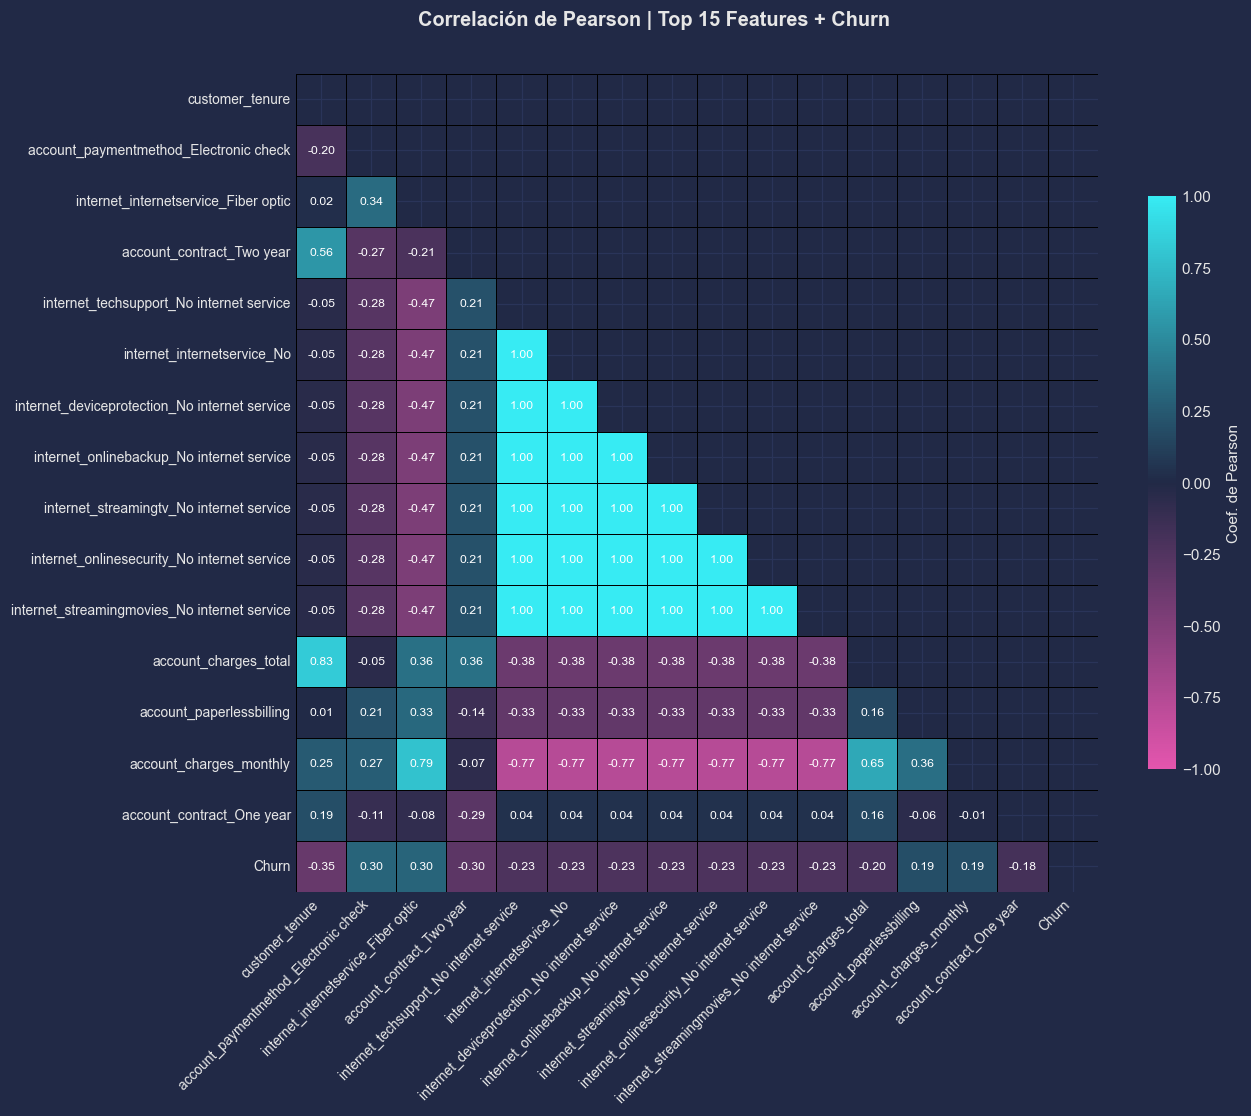

In [5]:
# Matriz de correlación de Pearson
corr_with_churn = compute_correlation(df_train)

# Heatmap — Top 15 features por correlación absoluta con Churn
plot_correlation_heatmap(df_train, corr_with_churn)

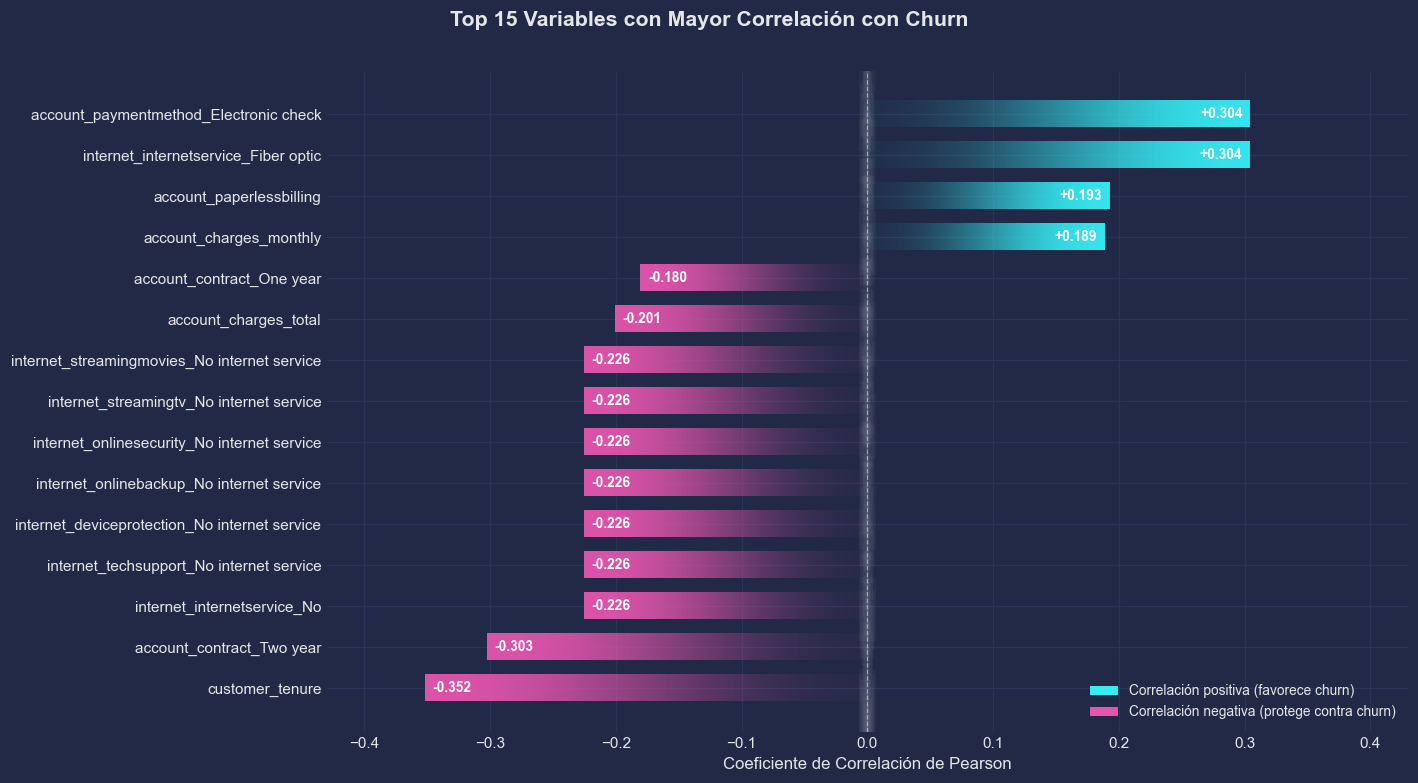

In [6]:
# Top 15 variables por correlación absoluta con Churn – barras horizontales
plot_correlation_bars(corr_with_churn)

### 📌 Hallazgos de la Correlación de Pearson

El ranking de correlaciones confirma y cuantifica lo que la Parte 1 identificó cualitativamente:

**Factores que impulsan el churn (correlación positiva):**
- `internet_internetservice_Fiber optic` y `account_paymentmethod_Electronic check` encabezan como los mayores predictores individuales de abandono.
- `account_charges_monthly` confirma que pagar más por mes aumenta el riesgo.
- `account_paperlessbilling` aparece junto al cheque electrónico, delineando un perfil de cliente digital con baja adherencia.

**Factores que protegen contra el churn (correlación negativa):**
- `customer_tenure` es el **protector más fuerte**.
- `account_contract_Two year` refuerza que el compromiso contractual es un escudo.
- Las columnas `internet_*_No internet service` revelan menor churn para clientes sin internet.

> **Limitación:** Pearson solo captura relaciones lineales. Variables con efecto no lineal (p.ej. tenure con curva de supervivencia) pueden tener un $|r|$ que subestima su verdadero poder predictivo. Por eso complementamos con Información Mutua a continuación.

### Información Mutua | Relaciones No Lineales

La Información Mutua (MI) cuantifica la **dependencia estadística** entre cada feature y el target sin asumir linealidad. Un score MI alto indica que la feature contiene información sobre el churn, independientemente del tipo de relación (lineal, cuadrática, de umbral, etc.).

Comparar el ranking de MI con Pearson nos permite identificar **features cuyo poder predictivo está subestimado** por la correlación lineal.

In [7]:
# Información Mutua
mi_scores = compute_mutual_information(X_train, y_train)

# Comparación Pearson vs MI
pearson_top15 = set(corr_with_churn.abs().nlargest(15).index)
mi_top15 = set(mi_scores.nlargest(15).index)

only_mi = mi_top15 - pearson_top15
only_pearson = pearson_top15 - mi_top15

if only_mi:
    print(f'\n🔍 Features en Top 15 MI pero NO en Top 15 Pearson (posibles relaciones no lineales):')
    for feat in only_mi:
        print(f'   MI={mi_scores[feat]:.4f}  |r|={corr_with_churn[feat].abs() if feat in corr_with_churn.index else 0:.4f}  {feat}')

if only_pearson:
    print(f'\n🔍 Features en Top 15 Pearson pero NO en Top 15 MI:')
    for feat in only_pearson:
        print(f'   |r|={corr_with_churn[feat].abs():.4f}  MI={mi_scores[feat]:.4f}  {feat}')

📊 Información Mutua — Features analizadas: 30

Top 10 features por MI con Churn:
   0.0724  customer_tenure
   0.0606  account_contract_Two year
   0.0496  account_charges_total
   0.0466  internet_internetservice_Fiber optic
   0.0446  account_paymentmethod_Electronic check
   0.0429  account_charges_monthly
   0.0307  internet_deviceprotection_No internet service
   0.0307  internet_techsupport_No internet service
   0.0307  internet_streamingmovies_No internet service
   0.0307  internet_streamingtv_No internet service

Bottom 5 (menor señal):
   0.0013  internet_streamingmovies_Yes
   0.0009  phone_multiplelines_Yes
   0.0001  customer_gender_Male
   0.0000  phone_multiplelines_No phone service
   0.0000  phone_phoneservice


### Análisis de Multicolinealidad (VIF)

El **Variance Inflation Factor** mide cuánto se infla la varianza de un coeficiente en modelos lineales debido a la correlación entre features. Es especialmente importante para Regresión Logística.

| VIF | Interpretación |
|---|---|
| 1 | Sin multicolinealidad |
| 1–5 | Moderada (aceptable) |
| 5–10 | Alta (considerar eliminar) |
| > 10 | Severa (eliminar o combinar) |

Analizamos las features numéricas principales para detectar redundancias estructurales.

In [8]:
# VIF sobre las features numéricas continuas del train set
# Limitamos a las features con mayor varianza para evitar problemas con dummies near-zero
vif_df = compute_vif(X_train, max_features=15)
vif_df.head(10)

=== Análisis de Multicolinealidad (VIF) ===

⚠️  4 features con VIF > 5 (multicolinealidad):
   🔴 ALTO  VIF=13.89     account_charges_monthly
   🔴 ALTO  VIF=10.43     account_charges_total
   🟡 MODERADO  VIF=6.09      customer_tenure
   🟡 MODERADO  VIF=5.46      internet_internetservice_Fiber optic

📊 VIF promedio: 3.50


,feature,VIF
0,account_charges_monthly,13.89
1,account_charges_total,10.43
2,customer_tenure,6.09
3,internet_internetservice_Fiber optic,5.46
4,internet_streamingmovies_Yes,2.05
5,internet_streamingtv_Yes,2.02
6,internet_techsupport_Yes,1.65
7,internet_deviceprotection_Yes,1.62
8,internet_onlinebackup_Yes,1.61
9,phone_multiplelines_Yes,1.55


---
## Paso 2: Análisis Dirigido

La correlación de Pearson nos da un número, pero no cuenta la historia completa. Para las variables continuas más ricas del dataset, el comportamiento distribucional es tan importante como el coeficiente.

Analizamos dos dimensiones clave que, combinadas, definen la "huella económica y temporal" de un cliente:

**A) Tiempo de contrato (`customer_tenure`):** El historial de permanencia del cliente. La hipótesis de la Parte 1 establece que el 80% del churn ocurre en los primeros 12 meses. Un boxplot revelará si las distribuciones de churned vs. retained son estadísticamente distintas y en qué magnitud.

**B) Estructura de gasto (`account_charges_monthly` y `account_charges_total`):** El cargo mensual es el desembolso recurrente percibido; el total acumulado es el valor histórico del cliente. Si los clientes que se van tienen cargos mensuales altos pero totales bajos, la lectura es clara: son clientes nuevos y caros que no están percibiendo valor suficiente.

> Los boxplots permiten comparar medianas, rangos intercuartílicos y presencia de outliers entre ambos grupos. El scatter plot `mensual × total` coloreado por Churn revela la zona de solapamiento donde el modelo deberá tomar decisiones más difíciles.

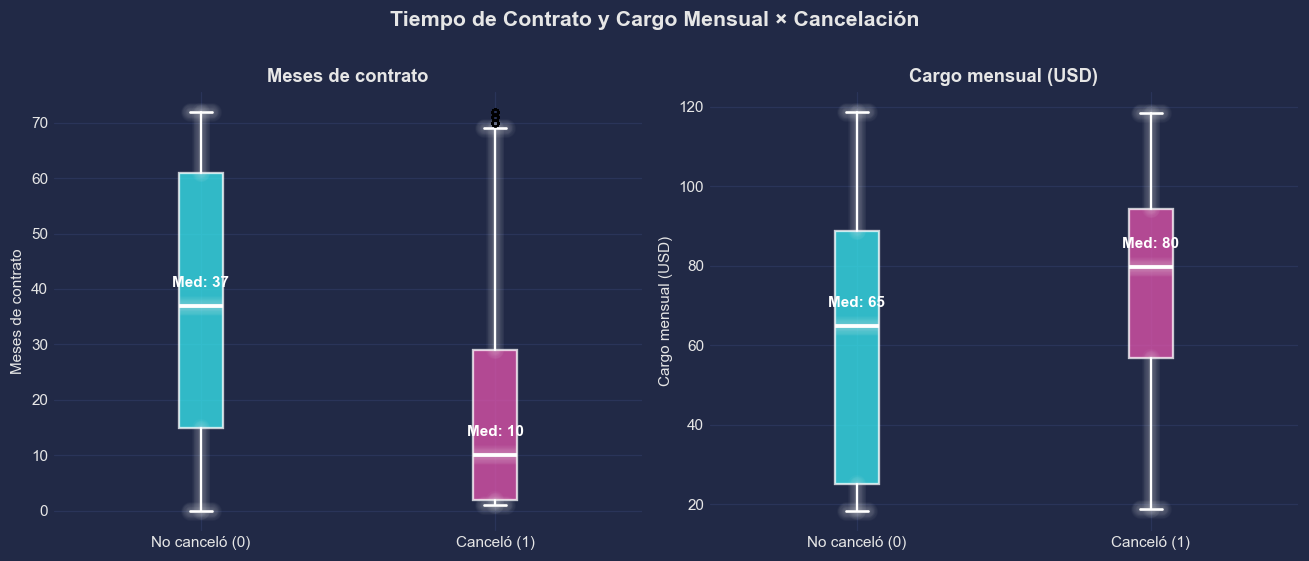

In [9]:
plot_boxplot_by_target(
    df_train,
    columns=['customer_tenure', 'account_charges_monthly'],
    ylabels=['Meses de contrato', 'Cargo mensual (USD)'],
    suptitle='Tiempo de Contrato y Cargo Mensual × Cancelación',
)

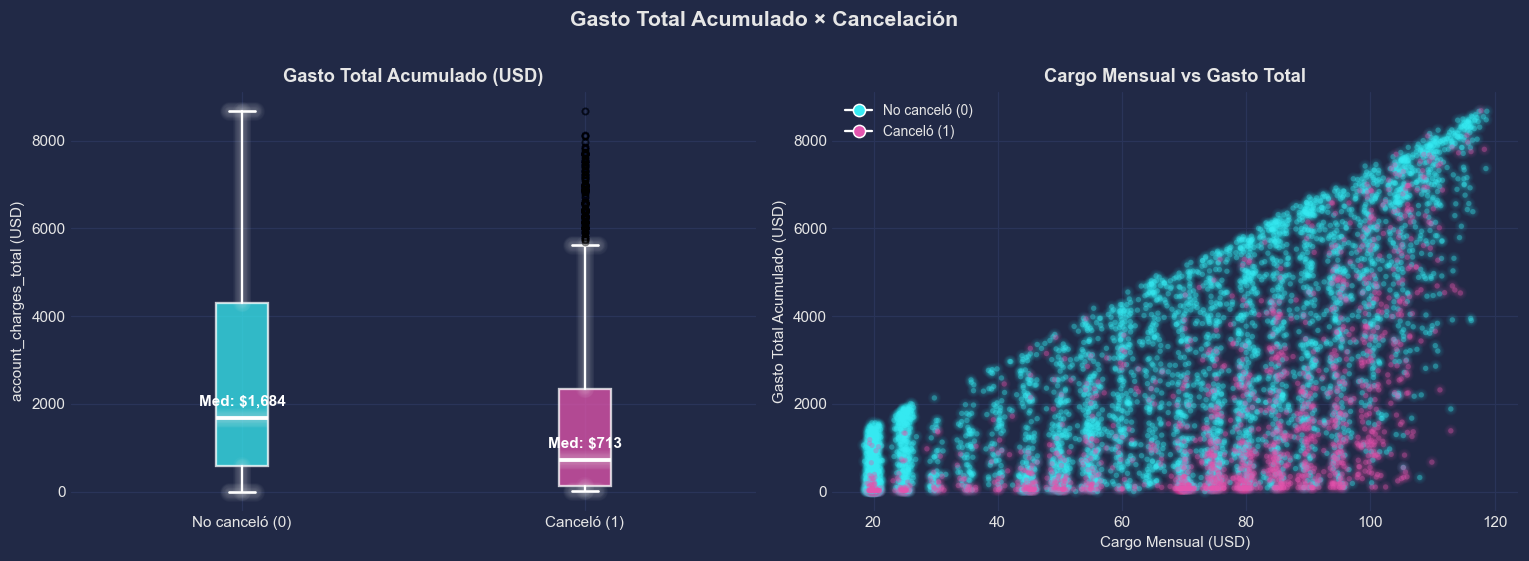

In [10]:
plot_charges_analysis(df_train)

### 📌 Hallazgos del Análisis Dirigido

**Tiempo de contrato (`customer_tenure`):**
Los clientes que cancelaron muestran una mediana de permanencia de **10 meses**, frente a los **38 meses** del grupo retenido. La distribución del grupo churned está claramente concentrada en los primeros meses, validando la **"ventana crítica"** identificada en la Parte 1: el riesgo de abandono es máximo al inicio de la relación y decrece con el tiempo. El modelo deberá dar mucho peso a este feature.

**Cargo mensual (`account_charges_monthly`):**
Contraintuitivamente, los clientes que se van tienen una mediana de cargo mensual de **$80**, frente a **$64** de los retenidos. Esto refuerza la **paradoja Fiber optic**: los servicios premium tienen mayor tasa de churn, posiblemente porque las expectativas de calidad no están siendo cumplidas o porque la competencia en ese segmento es más intensa.

**Gasto total acumulado (`account_charges_total`):**
La mediana del gasto total de churned es **$704** frente a **$1.680** de los retenidos: una diferencia de 2.4x que es consecuencia directa del tenure corto. En el scatter plot, los puntos rosas (churned) se distribuyen a lo largo de **todos los niveles de cargo mensual** pero quedan confinados en la banda inferior del gasto total: independientemente de cuánto paguen por mes, los clientes que abandonan lo hacen antes de acumular valor histórico. Esto refuerza que `customer_tenure` es el factor determinante, no el precio en sí.

> La combinación `tenure bajo + ausencia de servicios complementarios + contrato mensual` es el patrón de riesgo más claro que los modelos deberán aprender a detectar.

---
## Paso 3: Selección de Variables

Con el análisis de correlación, información mutua y VIF completados, estamos en condiciones de decidir qué variables llevar a los modelos.

### Estrategia dual

No todas las familias de algoritmos tienen la misma sensibilidad al ruido dimensional:

| Tipo de modelo | Sensible a features irrelevantes | Estrategia recomendada |
|---|---|---|
| **Árboles (Random Forest, XGBoost)** | Baja: el árbol ignora splits no informativos | Usar **todas las features** |
| **Regresión Logística** | Alta: coeficientes inflados por multicolinealidad y ruido | Filtrar por **umbral de correlación** |

### Umbral `|r| >= 0.15`

Adoptamos un umbral de `|r| >= 0.15` (subido desde 0.10 en la revisión) para la versión filtrada:
- $|r| = 0.15$ explica $r^2 = 2.25\%$ de la varianza — un mínimo de relevancia práctica.
- El umbral anterior de 0.10 retenía features con menos del 1% de varianza explicada (ruido).
- Variables que tienen baja correlación lineal pero alto MI pueden ser rescatadas por los modelos de árbol que usan todas las features.

### Variables que se descartan

Las features con `|r| < 0.15` son principalmente columnas dummy de servicios con baja adopción diferencial entre churned y retained, o variables demográficas con efecto marginal.

In [11]:
# Selección de features por umbral de correlación absoluta con Churn
selected_features, discarded_features = select_features_by_correlation(corr_with_churn)

# Creación de artefactos para modelos sensibles a escala (features filtradas)
X_train_sel        = X_train_bal[selected_features]
X_test_sel         = X_test[selected_features]

X_train_sel_scaled, X_test_sel_scaled, scaler_sel = scale_features(X_train_sel, X_test_sel)

print(f'\n✅ Artefactos generados:')
print(f'   X_train_sel        : {X_train_sel.shape}  (árboles, features seleccionadas)')
print(f'   X_test_sel         : {X_test_sel.shape}')
print(f'   X_train_sel_scaled : {X_train_sel_scaled.shape}  (modelos sensibles a escala)')
print(f'   X_test_sel_scaled  : {X_test_sel_scaled.shape}')

# ── Persistir la lista de features seleccionadas ──────────────────
features_artifact = {
    'selected_features': selected_features,
    'discarded_features': discarded_features,
    'threshold': CORR_THRESHOLD,
    'method': 'pearson_abs',
    'computed_on': 'X_train (sin leakage)',
}

features_path = DATA_PROCESSED_DIR / 'selected_features.json'
with open(features_path, 'w', encoding='utf-8') as f:
    json.dump(features_artifact, f, indent=2, ensure_ascii=False)

print(f'\n💾 Features seleccionadas exportadas: {features_path}')

=== Selección de Variables (umbral |r| >= 0.15) ===

  Features totales     : 30
  Features seleccionadas: 20
  Features descartadas  : 10

📋 Features seleccionadas (ordenadas por |correlación|):
   -0.3519  customer_tenure
   +0.3044  account_paymentmethod_Electronic check
   +0.3039  internet_internetservice_Fiber optic
   -0.3026  account_contract_Two year
   -0.2256  internet_techsupport_No internet service
   -0.2256  internet_internetservice_No
   -0.2256  internet_deviceprotection_No internet service
   -0.2256  internet_onlinebackup_No internet service
   -0.2256  internet_streamingtv_No internet service
   -0.2256  internet_onlinesecurity_No internet service
   -0.2256  internet_streamingmovies_No internet service
   -0.2010  account_charges_total
   +0.1927  account_paperlessbilling
   +0.1889  account_charges_monthly
   -0.1805  account_contract_One year
   -0.1712  internet_techsupport_Yes
   -0.1686  internet_onlinesecurity_Yes
   -0.1580  customer_dependents
   +0.1531  c

---
## ✅ Resumen de Correlación y Selección de Variables

### Mejoras metodológicas aplicadas

| Aspecto | Antes | Después |
|---|---|---|
| **Correlación calculada sobre** | `df_encoded` completo (leakage) | `X_train` solo (sin leakage) |
| **Métodos de asociación** | Solo Pearson (lineal) | Pearson + Información Mutua (no lineal) |
| **Multicolinealidad** | No analizada | VIF calculado y reportado |
| **Umbral de selección** | `\|r\| >= 0.10` (unjustified) | `\|r\| >= 0.15` ($r^2 = 2.25\%$ mínimo) |
| **Persistencia** | Solo en memoria | Exportado a `selected_features.json` |

### Variables críticas identificadas

| Dimensión | Variables clave | Dirección |
|---|---|---|
| **Contractual** | `account_contract_Two year`, `account_contract_One year` | Protectora |
| **Temporal** | `customer_tenure` | Protectora |
| **Pago** | `account_paymentmethod_Electronic check`, `account_paperlessbilling` | Riesgo |
| **Servicios** | `internet_onlinesecurity`, `internet_techsupport` | Protectora |
| **Internet** | `internet_internetservice_Fiber optic` | Riesgo |
| **Económica** | `account_charges_monthly` | Riesgo |

### Artefactos disponibles para el modelado

| Variable | Descripción | Para usar con |
|---|---|---|
| `X_train_bal`, `y_train_bal` | Train balanceado, **todas las features** | Random Forest, XGBoost |
| `X_train_sel`, `X_test_sel` | Train/test con **features seleccionadas** (`\|r\| >= 0.15`) | Random Forest, XGBoost |
| `X_train_sel_scaled`, `X_test_sel_scaled` | Train/test escalado, **features seleccionadas** | Regresión Logística |
| `X_test`, `y_test` | Test real sin modificar | Evaluación de todos los modelos |
| `scaler_sel` | Scaler ajustado en train (features sel.) | Transformar datos nuevos en producción |
| `selected_features.json` | Lista persistida de features seleccionadas | Reproducibilidad entre notebooks |